In [1]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import cmocean
import seaborn as sns

In [2]:
plt.style.use("nice.mplstyle")

In [3]:
import pandas as pd
import io
import matplotlib.dates as mdates

In [4]:
csv_fss="""FHR006,,,
threshold,GFS,HRRR,Nested-EAGLE
1,0.702,0.707,0.727
2,0.670,0.680,0.690
5,0.578,0.617,0.589
10,0.436,0.523,0.448
20,0.243,0.376,0.244
25,0.184,0.320,0.182
30,0.140,0.274,0.134
40,0.077,0.200,0.072
50,0.043,0.138,0.042
60,0.026,0.101,0.028
70,0.019,0.078,0.017
75,0.017,0.068,0.016
80,0.013,0.057,0.011
90,0.013,0.045,0.005
100,0.011,0.037,0.002
FHR24,,,
threshold,GFS,HRRR,Nested-EAGLE
1,0.656,0.651,0.664
2,0.609,0.610,0.610
5,0.494,0.521,0.484
10,0.348,0.416,0.323
20,0.182,0.265,0.141
25,0.135,0.214,0.092
30,0.103,0.175,0.059
40,0.052,0.118,0.023
50,0.026,0.079,0.010
60,0.013,0.052,0.004
70,0.009,0.037,0.000
75,0.007,0.031,0.000
80,0.007,0.027,0.000
90,0.004,0.018,0.000
100,0.005,0.017,0.000"""

In [5]:
def csv2fds(csvdata, rename_dict=None, nrows=15):

    csv_file = io.StringIO(csvdata)

    # Read the first table (FHR006) into a pandas DataFrame.
    # We skip the header row and read 15 rows of data.
    df_fhr6 = pd.read_csv(csv_file, skiprows=1, nrows=nrows)
    if rename_dict is not None:
        df_fhr6.rename(columns=rename_dict, inplace=True)
    df_fhr6['fhr'] = 6
    
    # Reset the file pointer to the beginning to read the second table.
    csv_file.seek(0)
    
    # Read the second table (FHR24). We skip to the correct row.
    df_fhr24 = pd.read_csv(csv_file, skiprows=nrows+3, nrows=nrows)
    if rename_dict is not None:
        df_fhr24.rename(columns=rename_dict, inplace=True)
    df_fhr24['fhr'] = 24
    
    # Concatenate the two DataFrames into a single one.
    df_combined = pd.concat([df_fhr6, df_fhr24])
    
    # Set the 'amount' and 'fhr' columns as the index. This is a crucial
    # step to define the dimensions for the xarray dataset.
    if rename_dict is not None:
        y = next(iter(rename_dict.values()))
    else:
        y = df_fhr24.columns.tolist()[0]
    if y == "time":
        df_combined['time'] = pd.to_datetime(df_combined['time'])
    df_combined = df_combined.set_index([y, 'fhr'])
    
    # Convert the pandas DataFrame to an xarray Dataset.
    return xr.Dataset.from_dataframe(df_combined)


In [6]:
#fds = csv2fds(csv_fss), {})#{'Amount (mm)': 'amount'})
fds = csv2fds(csv_fss)

In [7]:
nds = xr.open_dataset("/pscratch/sd/t/timothys/nested-eagle/0.25deg-06km/production/gfs-hrrr/stage1c/inference-precip-validation/fss/fss.nested-lam.nc")
hds = xr.open_dataset("/pscratch/sd/t/timothys/nested-eagle/0.25deg-06km/baselines/hrrr-forecasts-vs-aorc/fss-validation/fss.lam.nc")
gds = xr.open_dataset("/pscratch/sd/t/timothys/nested-eagle/0.25deg-06km/baselines/gfs-forecasts-vs-aorc/fss-validation/fss.lam.nc")

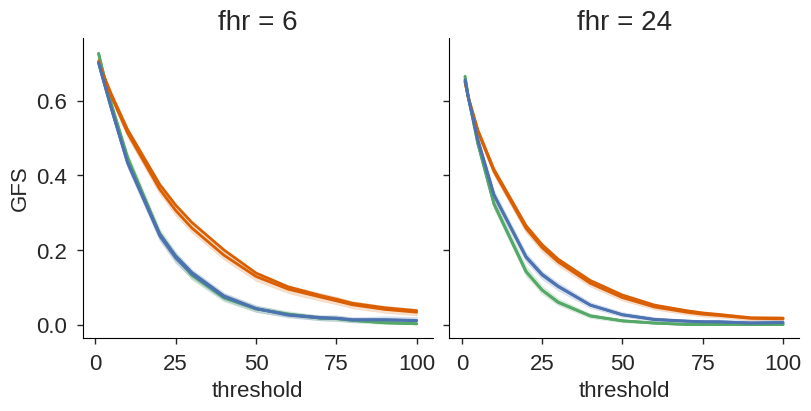

In [8]:
fig, axs = plt.subplots(1,2, figsize=(8,4), constrained_layout=True, sharey=True)
for fhr, ax in zip([6, 24], axs):
    for xds, name, color in zip(
        [nds, hds, gds],
        ["Nested-EAGLE", "HRRR", "GFS"],
        ["C0", "C1", "C2"],
    ):
        me = xds.fss.sel(fhr=fhr)
        df = me.to_dataframe().reset_index()
        sns.lineplot(
            df,
            x="threshold",
            y="fss",
            ax=ax,
            color=color,
        )
        brett = fds[name].sel(fhr=fhr)
        brett.plot(color=color, ax=ax)

## Percentiles

In [10]:
csv_fsst="""FHR006,,,
Percentile,GFS,HRRR,Nested-EAGLE
5,0.730,0.754,0.758
10,0.720,0.751,0.756
25,0.706,0.747,0.752
50,0.686,0.733,0.736
75,0.636,0.696,0.696
90,0.558,0.632,0.628
95,0.486,0.576,0.562
99,0.305,0.415,0.372
99.9,0.116,0.208,0.167
FHR24,,,
Percentile,GFS,HRRR,Nested-EAGLE
5,0.710,0.681,0.724
10,0.700,0.677,0.721
25,0.684,0.664,0.711
50,0.653,0.635,0.682
75,0.583,0.575,0.616
90,0.479,0.495,0.522
95,0.397,0.434,0.444
99,0.228,0.280,0.269
99.9,0.086,0.128,0.114"""

In [11]:
tds = csv2fds(csv_fsst, nrows=9)

In [17]:
pnds = xr.open_dataset("/pscratch/sd/t/timothys/nested-eagle/0.25deg-06km/production/gfs-hrrr/stage1c/inference-precip-validation/fss/fss.percentile.nested-lam.nc")
phds = xr.open_dataset("/pscratch/sd/t/timothys/nested-eagle/0.25deg-06km/baselines/hrrr-forecasts-vs-aorc/fss-validation/fss.percentile.lam.nc")
pgds = xr.open_dataset("/pscratch/sd/t/timothys/nested-eagle/0.25deg-06km/baselines/gfs-forecasts-vs-aorc/fss-validation/fss.percentile.lam.nc")

In [21]:
phds.pfss.sel(percentile=75,fhr=6).mean("t0")

<xarray.DataArray 'pfss' (radius: 1)> Size: 8B
array([0.69271138])
Coordinates:
  * radius      (radius) int64 8B 25
    lead_time   timedelta64[ns] 8B ...
    fhr         int64 8B 6
    percentile  float64 8B 75.0
Attributes: (12/38)
    GRIB_DxInMetres:                          3000.0
    GRIB_DyInMetres:                          3000.0
    GRIB_LaDInDegrees:                        38.5
    GRIB_Latin1InDegrees:                     38.5
    GRIB_Latin2InDegrees:                     38.5
    GRIB_LoVInDegrees:                        262.5
    ...                                       ...
    standard_name:                            unknown
    AORC_Contact:                             aorc.info@noaa.gov
    aorc_version:                             v1.1
    crs:                                      EPSG:4326
    level:                                    surface
    short_name:                               APCP_surface

In [19]:
tds["HRRR"].sel(fhr=6,Percentile=75)

<xarray.DataArray 'HRRR' ()> Size: 8B
array(0.696)
Coordinates:
    Percentile  float64 8B 75.0
    fhr         int64 8B 6

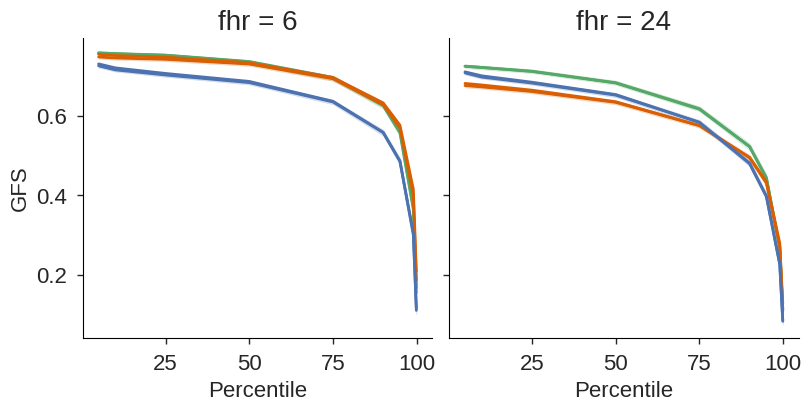

In [20]:
fig, axs = plt.subplots(1,2, figsize=(8,4), constrained_layout=True, sharey=True)
for fhr, ax in zip([6, 24], axs):
    for xds, name, color in zip(
        [pnds, phds, pgds],
        ["Nested-EAGLE", "HRRR", "GFS"],
        ["C0", "C1", "C2"],
    ):
        me = xds.pfss.sel(fhr=fhr)
        df = me.to_dataframe().reset_index()
        sns.lineplot(
            df,
            x="percentile",
            y="pfss",
            ax=ax,
            color=color,
        )
        brett = tds[name].sel(fhr=fhr)
        brett.plot(color=color, ax=ax)